In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("US_Customer_Insights_Dataset.csv")

In [3]:
df

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103
...,...,...,...,...,...,...,...,...,...,...,...,...
10670,CUST10833,Steven Burns,Georgia,PhD,Female,60,No,1,8/24/23,2/29/24,341.28,518
10671,CUST10620,Jesse Pratt,Texas,Master,Male,64,No,0,4/13/23,12/31/24,468.04,212
10672,CUST10449,John Lloyd,Arizona,Master,Non-Binary,31,Yes,0,7/3/22,9/21/23,259.94,679
10673,CUST10020,Christopher Sparks,Florida,Bachelor,Female,31,No,0,9/19/23,12/29/23,494.17,580


In [4]:
df.head()

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103


In [5]:
df.dtypes

CustomerID                   object
Name                         object
State                        object
Education                    object
Gender                       object
Age                           int64
Married                      object
NumPets                       int64
JoinDate                     object
TransactionDate              object
MonthlySpend                float64
DaysSinceLastInteraction      int64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10675 non-null  object 
 1   Name                      10675 non-null  object 
 2   State                     10675 non-null  object 
 3   Education                 10675 non-null  object 
 4   Gender                    10675 non-null  object 
 5   Age                       10675 non-null  int64  
 6   Married                   10675 non-null  object 
 7   NumPets                   10675 non-null  int64  
 8   JoinDate                  10675 non-null  object 
 9   TransactionDate           10675 non-null  object 
 10  MonthlySpend              10675 non-null  float64
 11  DaysSinceLastInteraction  10675 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1000.9+ KB


In [7]:
df.isnull().sum()

CustomerID                  0
Name                        0
State                       0
Education                   0
Gender                      0
Age                         0
Married                     0
NumPets                     0
JoinDate                    0
TransactionDate             0
MonthlySpend                0
DaysSinceLastInteraction    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.nunique()

CustomerID                  1000
Name                         990
State                         10
Education                      5
Gender                         3
Age                           63
Married                        2
NumPets                        5
JoinDate                     731
TransactionDate             1605
MonthlySpend                9843
DaysSinceLastInteraction    1605
dtype: int64

In [10]:
#All numerical columns 
df.select_dtypes([int,float])

,Age,NumPets,MonthlySpend,DaysSinceLastInteraction
0,47,1,1281.74,332
1,72,0,429.46,424
2,40,2,510.34,153
3,27,0,396.47,124
4,28,1,139.68,1103
...,...,...,...,...
10670,60,1,341.28,518
10671,64,0,468.04,212
10672,31,0,259.94,679
10673,31,0,494.17,580


In [11]:
#All categorical columns 
df.select_dtypes(object)

,CustomerID,Name,State,Education,Gender,Married,JoinDate,TransactionDate
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,Yes,9/19/21,9/2/24
1,CUST10695,Jennifer Burton,Washington,Master,Male,Yes,4/5/24,6/2/24
2,CUST10297,Michelle Rogers,Arizona,Master,Female,Yes,7/24/24,2/28/25
3,CUST10103,Brooke Hendricks,Texas,Master,Male,Yes,8/12/23,3/29/25
4,CUST10219,Karen Johns,Texas,High School,Female,Yes,12/6/21,7/24/22
...,...,...,...,...,...,...,...,...
10670,CUST10833,Steven Burns,Georgia,PhD,Female,No,8/24/23,2/29/24
10671,CUST10620,Jesse Pratt,Texas,Master,Male,No,4/13/23,12/31/24
10672,CUST10449,John Lloyd,Arizona,Master,Non-Binary,Yes,7/3/22,9/21/23
10673,CUST10020,Christopher Sparks,Florida,Bachelor,Female,No,9/19/23,12/29/23


# Insight 📊

In [12]:
#Convert object column into date time 
df["JoinDate"]=pd.to_datetime(df["JoinDate"])
df["TransactionDate"]=pd.to_datetime(df["TransactionDate"])

# Descriptive Statistics

In [13]:
df[['Age','MonthlySpend', 'DaysSinceLastInteraction']].agg(["mean","median","std"]).T

,mean,median,std
Age,49.474567,49.00,18.221365
MonthlySpend,331.610315,282.11,225.799253
DaysSinceLastInteraction,538.469883,445.00,398.766747


In [14]:
df[['Age','MonthlySpend', 'DaysSinceLastInteraction']].describe()

,Age,MonthlySpend,DaysSinceLastInteraction
count,10675.000000,10675.000000,10675.000000
mean,49.474567,331.610315,538.469883
std,18.221365,225.799253,398.766747
min,18.000000,3.890000,1.000000
25%,35.000000,165.495000,218.000000
50%,49.000000,282.110000,445.000000
75%,66.000000,443.255000,788.500000
max,80.000000,1740.420000,1791.000000


In [15]:
df[['Education', 'Gender', 'Married']].mode()

,Education,Gender,Married
0,Master,Male,No


In [16]:
df.skew(numeric_only=True)

Age                        -0.015631
NumPets                     0.563461
MonthlySpend                1.421735
DaysSinceLastInteraction    0.800701
dtype: float64

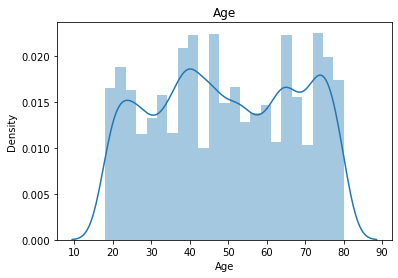

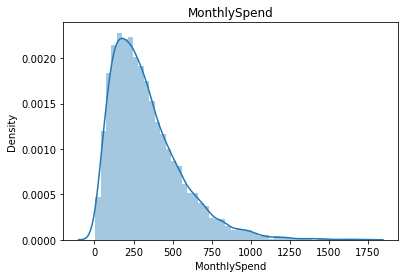

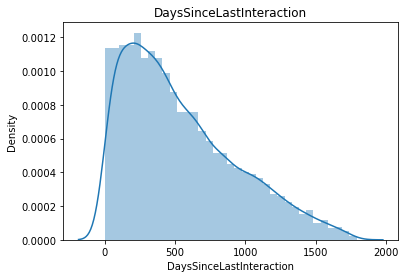

In [17]:
for i in df[['Age', 'MonthlySpend', 'DaysSinceLastInteraction']].columns:
    sns.distplot(df[i])
    plt.title(i)
    plt.show()

# Insight

In [18]:
print((df['MonthlySpend'] < 500).mean()*100)
print((df['MonthlySpend'] > 1000).mean()*100)

80.82435597189695
1.395784543325527


In [19]:
print((df['DaysSinceLastInteraction'] < 200).mean()*100)
print((df['DaysSinceLastInteraction'] > 1000).mean()*100)

22.6135831381733
15.185011709601874


# Data Visualization

In [20]:
# Plot histograms and boxplots for Age, MonthlySpend 

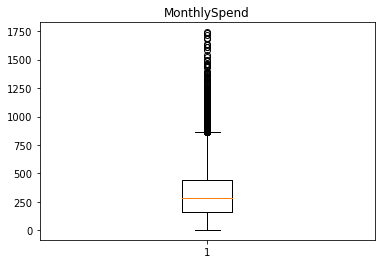

In [21]:
plt.boxplot(df["MonthlySpend"])
plt.title("MonthlySpend")
plt.show()

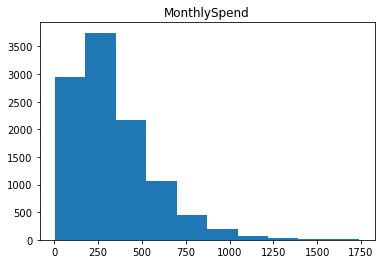

In [22]:
plt.hist(df["MonthlySpend"])
plt.title("MonthlySpend")
plt.show()

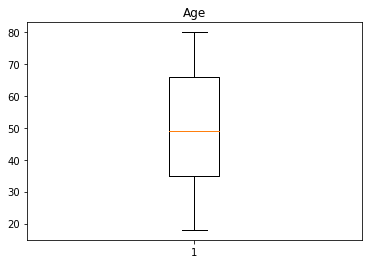

In [23]:
plt.boxplot(df["Age"])
plt.title("Age")
plt.show()

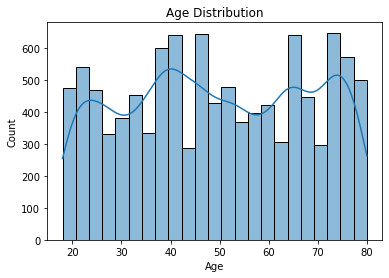

In [24]:
sns.histplot(df['Age'],kde=True)
plt.title("Age Distribution")
plt.show()

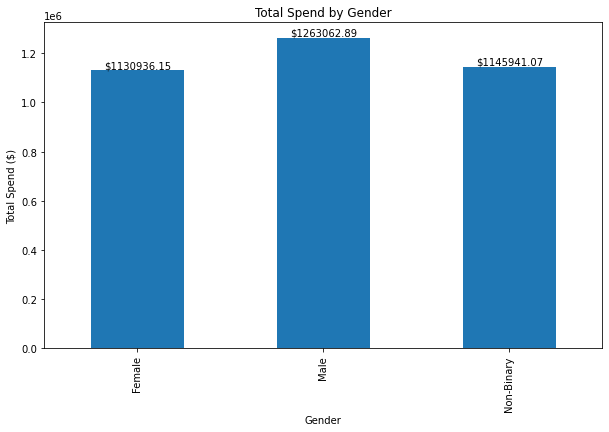

In [25]:
OP = df.groupby("Gender")["MonthlySpend"].sum().plot(kind='bar',figsize=(10,6))
for p in OP.patches:
    OP.annotate(
        f"${round(p.get_height(), 2)}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom'
    )
plt.title("Total Spend by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Spend ($)")
plt.show()

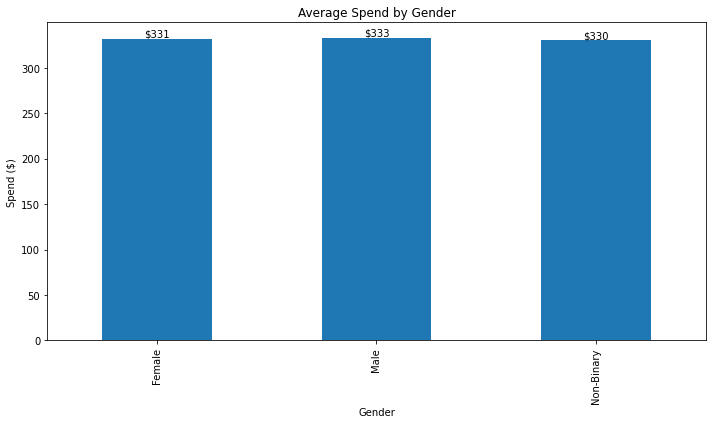

In [26]:
OP = df.groupby("Gender")["MonthlySpend"].mean().plot(kind='bar',figsize=(10,6))
for container in OP.containers:
     OP.bar_label(container, fmt='$%.f')  
plt.title("Average Spend by Gender")
plt.xlabel("Gender")
plt.ylabel("Spend ($)")
plt.tight_layout()
plt.show()


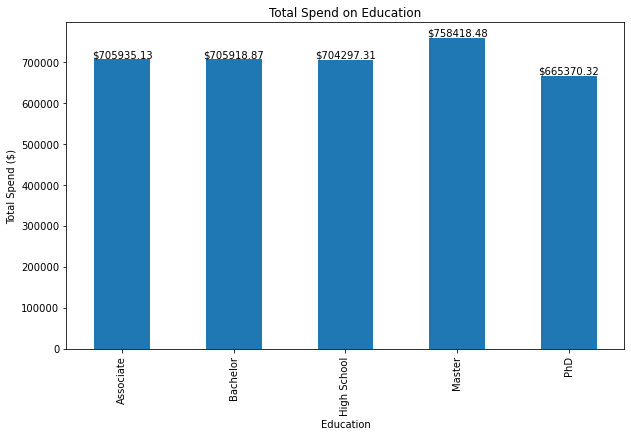

In [27]:
OP = df.groupby("Education")["MonthlySpend"].sum().plot(kind='bar',figsize=(10,6))
for p in OP.patches:
    OP.annotate(
        f"${round(p.get_height(), 2)}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom'
    )
plt.title("Total Spend on Education")
plt.xlabel("Education")
plt.ylabel("Total Spend ($)")
plt.show()

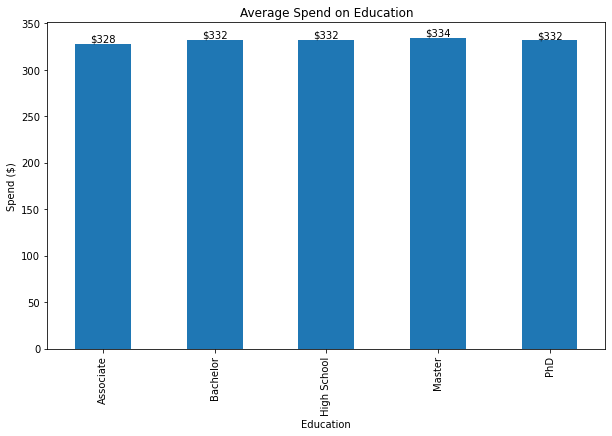

In [28]:
OP = df.groupby("Education")["MonthlySpend"].mean().plot(kind='bar',figsize=(10,6))
for container in OP.containers:
     OP.bar_label(container, fmt='$%.f') 
plt.title("Average Spend on Education")
plt.xlabel("Education")
plt.ylabel("Spend ($)")
plt.show()

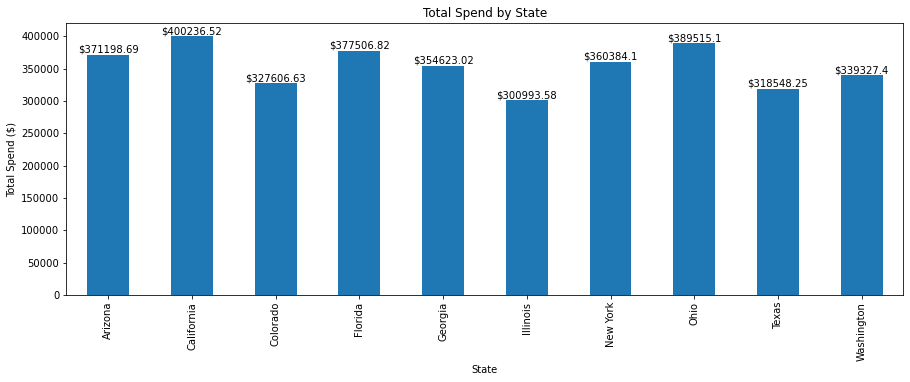

In [29]:
OP = df.groupby("State")["MonthlySpend"].sum().plot(kind='bar',figsize=(15,5))
for p in OP.patches:
    OP.annotate(
        f"${round(p.get_height(), 2)}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom'
    )
plt.title("Total Spend by State")
plt.xlabel("State")
plt.ylabel("Total Spend ($)")
plt.show()

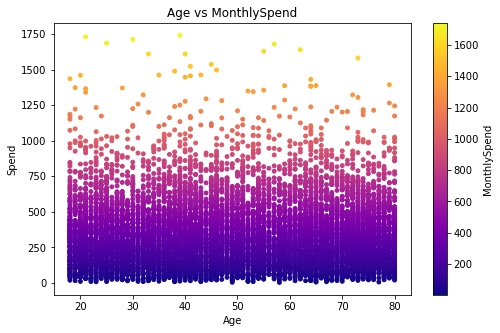

In [30]:
# Scatterplot: Age vs MonthlySpend 
plt.figure(figsize=(8,5))
plt.scatter(df["Age"], df["MonthlySpend"], c=df["MonthlySpend"], cmap="plasma", s=15)
plt.colorbar(label="MonthlySpend")
plt.title("Age vs MonthlySpend")
plt.xlabel("Age")
plt.ylabel("Spend")
plt.show()

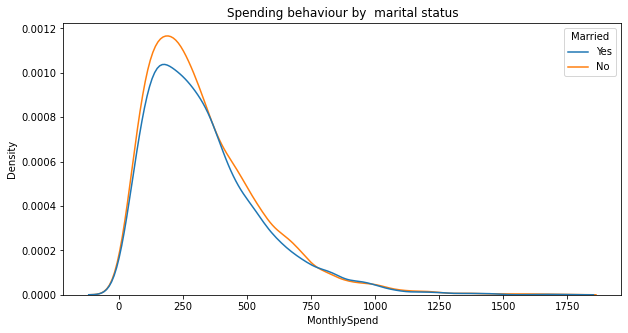

In [31]:
# KDE: Spending behaviour by  marital status
plt.figure(figsize=(10,5))
plt.title("Spending behaviour by  marital status")
sns.kdeplot(data =df ,x ="MonthlySpend",hue ="Married")
plt.show()

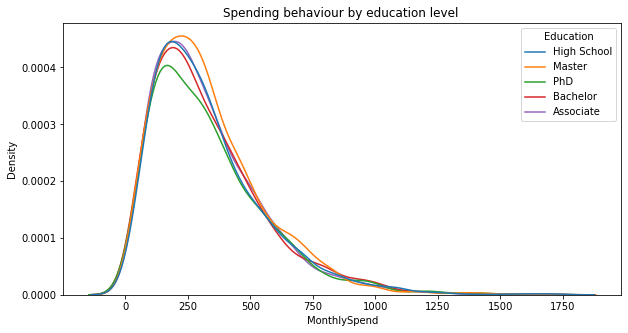

In [32]:
# KDE: Spending behaviour by education level 
plt.figure(figsize=(10,5))
plt.title("Spending behaviour by education level ")
sns.kdeplot(data =df ,x ="MonthlySpend",hue ="Education")
plt.show()

# Bivariate Analysis

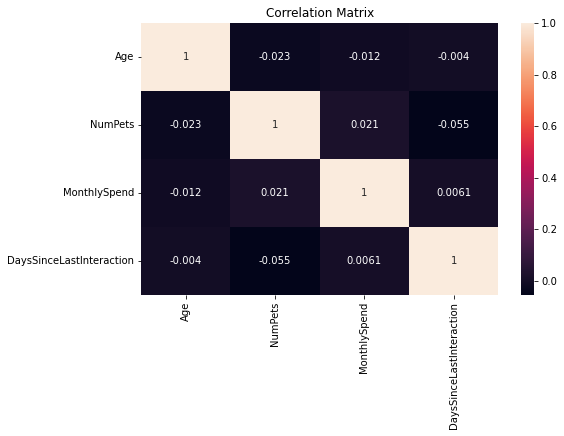

In [33]:
cor =df.select_dtypes([int,float]).corr()
plt.figure(figsize=(8,5))
sns.heatmap(cor,annot=True)
plt.title("Correlation Matrix")
plt.show()
plt.show()

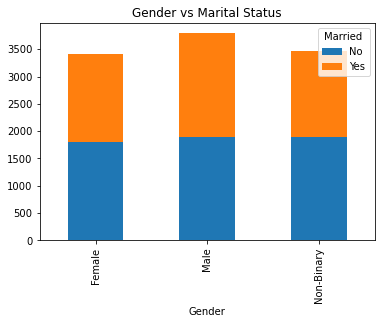

In [34]:
ct = pd.crosstab(df["Gender"],df["Married"])
ct.plot(kind='bar', stacked=True)
plt.title("Gender vs Marital Status")
plt.show()

In [35]:
result = {
    "Gender": df.groupby("Gender")["MonthlySpend"].mean(),
    "Education": df.groupby("Education")["MonthlySpend"].mean(),
    "State": df.groupby("State")["MonthlySpend"].mean()
}

for key, value in result.items():
    print(f"\n* {key} Avg Monthly Spend:\n{value}")


* Gender Avg Monthly Spend:
Gender
Female        331.361310
Male          333.174068
Non-Binary    330.147240
Name: MonthlySpend, dtype: float64

* Education Avg Monthly Spend:
Education
Associate      327.884408
Bachelor       331.884753
High School    332.215712
Master         334.252305
PhD            331.690090
Name: MonthlySpend, dtype: float64

* State Avg Monthly Spend:
State
Arizona       341.489135
California    339.183492
Colorado      323.083462
Florida       327.696892
Georgia       328.354648
Illinois      332.589591
New York      332.151244
Ohio          340.187860
Texas         319.506770
Washington    329.444078
Name: MonthlySpend, dtype: float64


In [36]:
df.select_dtypes([int,float]).corr()

,Age,NumPets,MonthlySpend,DaysSinceLastInteraction
Age,1.000000,-0.023035,-0.012323,-0.003970
NumPets,-0.023035,1.000000,0.020647,-0.055227
MonthlySpend,-0.012323,0.020647,1.000000,0.006081
DaysSinceLastInteraction,-0.003970,-0.055227,0.006081,1.000000


# Formulate hypothesis

##### 1.Do males and females spend differently ?

In [37]:
from scipy.stats import ttest_ind

In [38]:
male = df[df['Gender']=="Male"]["MonthlySpend"].dropna()
female = df[df['Gender']=="Female"]["MonthlySpend"].dropna()

from scipy.stats import ttest_ind

t_test, p_value = ttest_ind(male, female, equal_var=False)

print("T-Statistic:", round(t_test, 3))
print("P-value:", round(p_value, 4))
print("\nConclusion:")
if p_value < 0.05:
    print("There is a statistically significant difference in spending between genders.")
else:
    print("There is no statistically significant difference in spending between genders.")

T-Statistic: 0.339
P-value: 0.7345

Conclusion:
There is no statistically significant difference in spending between genders.


##### 2. Does education level impact average monthly spend?

In [39]:
from scipy.stats import f_oneway

groups = [df[df['Education']==edu]['MonthlySpend'].dropna() 
          for edu in df['Education'].unique()]

f_stat, p_val = f_oneway(*groups)

print("P-value:",round(p_val,4))

P-value: 0.9224


##### 3. Are older people less active?

In [40]:
df["Age"].corr(df["DaysSinceLastInteraction"])

-0.00397023010495504

###### 4. Does state-wise spend vary significantly?

In [41]:
from scipy import stats
groups = [group["MonthlySpend"].values for name, group in df.groupby("State")]
f_stat, p_value = stats.f_oneway(*groups)
print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1.1178423640877182
P-value: 0.34571886479238273


In [42]:
mean_diff = male.mean() - female.mean()
ci = 1.96 * np.sqrt(male.var()/len(male) + female.var()/len(female))

print("Confidence Interval:", (mean_diff - ci, mean_diff + ci))

Confidence Interval: (-8.664054788635479, 12.28957044892108)


# Business insight 📊

# Strategic Summary